# Treatment Facility Analysis Dashboard
## Milestone 2
### Medical Operations Dashboard

In [1]:
# Import Libraries

import pandas as pd
import plotly.express as px
from IPython.display import display, HTML


In [3]:
# step 1: Load Data
import pandas as pd
df = pd.read_csv("../Data/processed/medical_operations_master (1).csv")

df.head()

,Patient_ID,Age,Gender,Department_Patient,Diagnosis,Severity_Level,Admission_Date,Discharge_Date,Length_of_Stay_Days,Wait_Time_Minutes,...,Hospital_Name,Branch,City,State,Hospital_Type,Total_Beds,Latitude,Longitude,Nurse_ID,Nurse_Name
0,PAT000001,23,Male,Gynecology,Cancer,Low,02-05-2026,04-05-2026,2,79,...,CARE Hospitals,Banjara Hills,Hyderabad,Telangana,Private,435,17.3850,78.4867,N289,Deepak Verma
1,PAT000002,48,Male,Neurology,Kidney Disease,Medium,24-03-2026,30-03-2026,6,167,...,PGIMER,Sector 12,Chandigarh,Chandigarh,Government,1740,30.7333,76.7794,N053,Pooja Singh
2,PAT000003,63,Male,Neurology,Stroke,Low,07-09-2025,10-09-2025,3,281,...,Fortis Hospital,Jaipur,Jaipur,Rajasthan,Private,350,26.9124,75.7873,N051,Priya Kumar
3,PAT000004,85,Male,Emergency,Asthma,Medium,19-11-2024,21-11-2024,2,271,...,KIMS Hospital,Secunderabad,Hyderabad,Telangana,Private,600,17.3850,78.4867,N290,Meera Nair
4,PAT000005,93,Female,Neurology,Pneumonia,Medium,20-07-2024,27-07-2024,7,112,...,Apollo Hospital,Greams Road,Chennai,Tamil Nadu,Private,600,13.0827,80.2707,N112,Rahul Verma


## Step 2 - Exploratory Data Analysis (EDA)

In [3]:
#data information
df.info()
#data description
df.describe(include="all")
#missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           100000 non-null  object 
 1   Age                  100000 non-null  int64  
 2   Gender               100000 non-null  object 
 3   Department_Patient   100000 non-null  object 
 4   Diagnosis            100000 non-null  object 
 5   Severity_Level       100000 non-null  object 
 6   Admission_Date       100000 non-null  object 
 7   Discharge_Date       100000 non-null  object 
 8   Length_of_Stay_Days  100000 non-null  int64  
 9   Wait_Time_Minutes    100000 non-null  int64  
 10  Doctor_ID            100000 non-null  object 
 11  Insurance_Type       100000 non-null  object 
 12  Treatment_Cost_USD   100000 non-null  int64  
 13  Readmission_Flag     100000 non-null  int64  
 14  Outcome              100000 non-null  object 
 15  Doctor_Name       

Patient_ID             0
Age                    0
Gender                 0
Department_Patient     0
Diagnosis              0
Severity_Level         0
Admission_Date         0
Discharge_Date         0
Length_of_Stay_Days    0
Wait_Time_Minutes      0
Doctor_ID              0
Insurance_Type         0
Treatment_Cost_USD     0
Readmission_Flag       0
Outcome                0
Doctor_Name            0
Department_Doctor      0
Hospital_ID            0
Hospital_Name          0
Branch                 0
City                   0
State                  0
Hospital_Type          0
Total_Beds             0
Latitude               0
Longitude              0
Nurse_ID               0
Nurse_Name             0
dtype: int64

## Step 3 - KPI Creation

In [4]:
from IPython.display import display, HTML

total_patients = df["Patient_ID"].nunique()

total_departments = df["Department_Patient"].nunique()

gov_hospitals = (df["Hospital_Type"]=="Government").sum()

private_hospitals = (df["Hospital_Type"]=="Private").sum()

avg_beds = round(df["Total_Beds"].mean())

recovered = (df["Outcome"]=="Recovered").sum()

#DISPLAY KPIs CARD
display(HTML(f"""

<div style="display:flex;flex-wrap:wrap;gap:20px">

<div style="background:#4CAF50;color:white;padding:20px;border-radius:10px;width:220px;text-align:center;">
<h3>Total Patients</h3>
<h2>{total_patients}</h2>
</div>

<div style="background:#2196F3;color:white;padding:20px;border-radius:10px;width:220px;text-align:center;">
<h3>Departments</h3>
<h2>{total_departments}</h2>
</div>

<div style="background:#FF9800;color:white;padding:20px;border-radius:10px;width:220px;text-align:center;">
<h3>Government Hospitals</h3>
<h2>{gov_hospitals}</h2>
</div>

<div style="background:#9C27B0;color:white;padding:20px;border-radius:10px;width:220px;text-align:center;">
<h3>Private Hospitals</h3>
<h2>{private_hospitals}</h2>
</div>

<div style="background:#F44336;color:white;padding:20px;border-radius:10px;width:220px;text-align:center;">
<h3>Average Beds</h3>
<h2>{ avg_beds}</h2>
</div>

<div style="background:#009688;color:white;padding:20px;border-radius:10px;width:220px;text-align:center;">
<h3>Recovered Patients</h3>
<h2>{recovered}</h2>
</div>

</div>

"""))

##  - Department-wise Patient Distribution

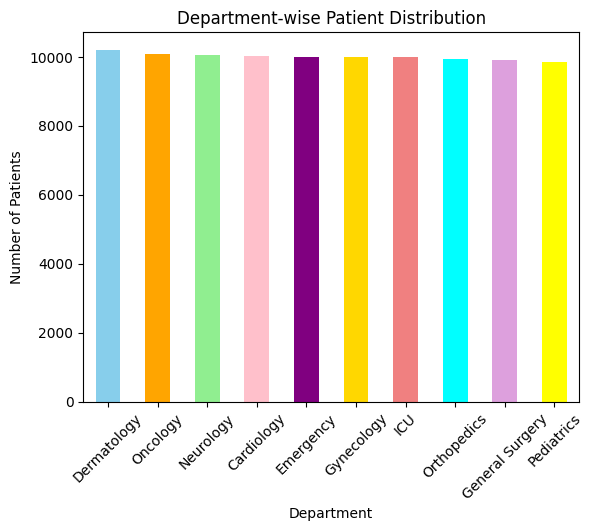

In [5]:
import matplotlib.pyplot as plt

df["Department_Patient"].value_counts().plot(
    kind="bar",
    color=[
        "skyblue",
        "orange",
        "lightgreen",
        "pink",
        "purple",
        "gold",
        "lightcoral",
        "cyan",
        "plum",
        "yellow"
    ]
)

plt.title("Department-wise Patient Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

## Hospital-wise Patient Distribution

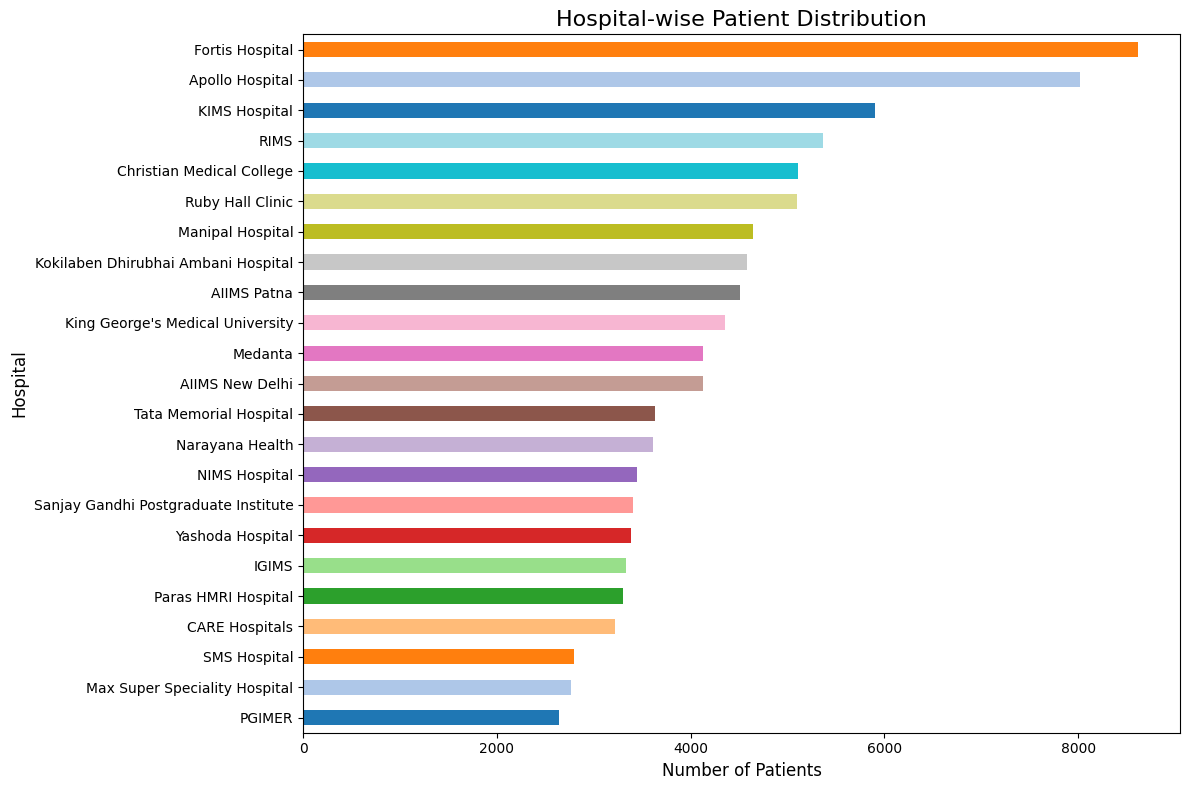

In [7]:
import matplotlib.pyplot as plt

hospital = df.groupby("Hospital_Name").size().sort_values(ascending=True)

plt.figure(figsize=(12, 8))

hospital.plot(
    kind="barh",
    color=plt.cm.tab20.colors
)

plt.title("Hospital-wise Patient Distribution", fontsize=16)
plt.xlabel("Number of Patients", fontsize=12)
plt.ylabel("Hospital", fontsize=12)

plt.tight_layout()
plt.show()

## Hospital Type Distribution

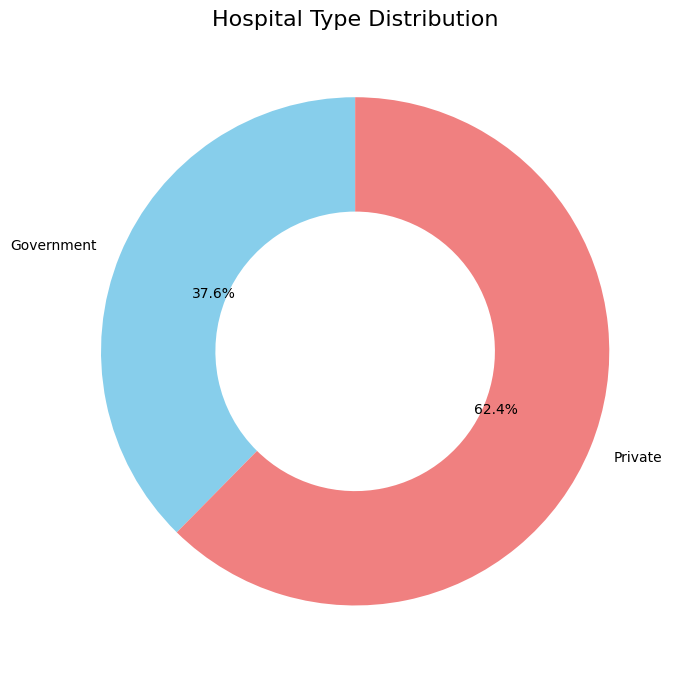

In [8]:
import matplotlib.pyplot as plt

facility = df.groupby("Hospital_Type").size()

plt.figure(figsize=(7, 7))

plt.pie(
    facility.values,
    labels=facility.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "lightcoral"],
    wedgeprops={"width": 0.45}
)

plt.title("Hospital Type Distribution", fontsize=16)

plt.tight_layout()
plt.show()

## Severity Distribution

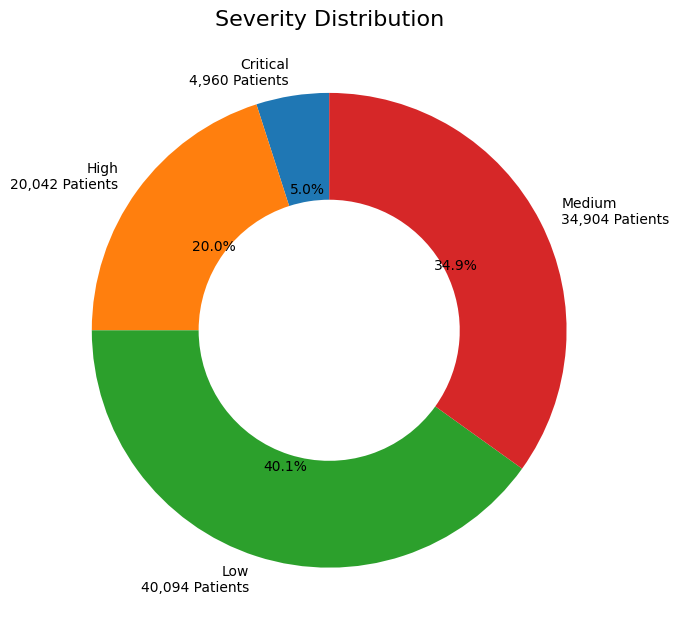

In [9]:
import matplotlib.pyplot as plt

severity = df.groupby("Severity_Level").size()

labels = [
    f"{level}\n{count:,} Patients"
    for level, count in severity.items()
]

plt.figure(figsize=(7, 7))

plt.pie(
    severity.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Severity Distribution", fontsize=16)

plt.tight_layout()
plt.show()

## Treatment Cost Distribution

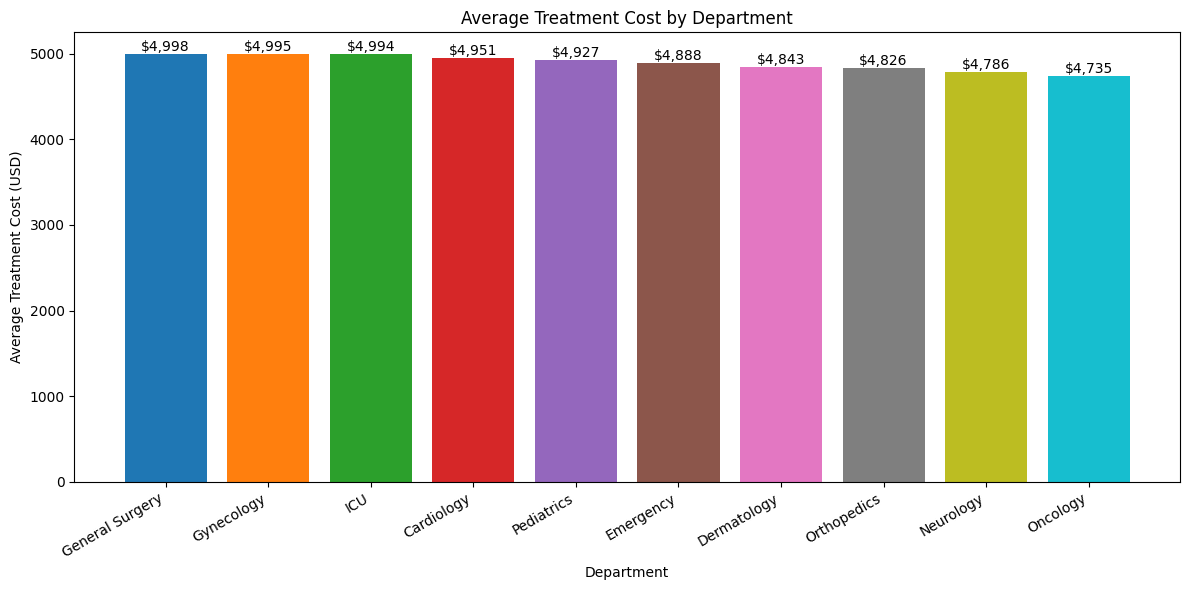

In [16]:
import matplotlib.pyplot as plt

cost = df.groupby("Department_Patient")["Treatment_Cost_USD"].mean().sort_values(ascending=False)

colors = plt.cm.tab10.colors

plt.figure(figsize=(12, 6))

bars = plt.bar(cost.index, cost.values, color=colors)

plt.title("Average Treatment Cost by Department")
plt.xlabel("Department")
plt.ylabel("Average Treatment Cost (USD)")
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, cost.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Average Stay by Department

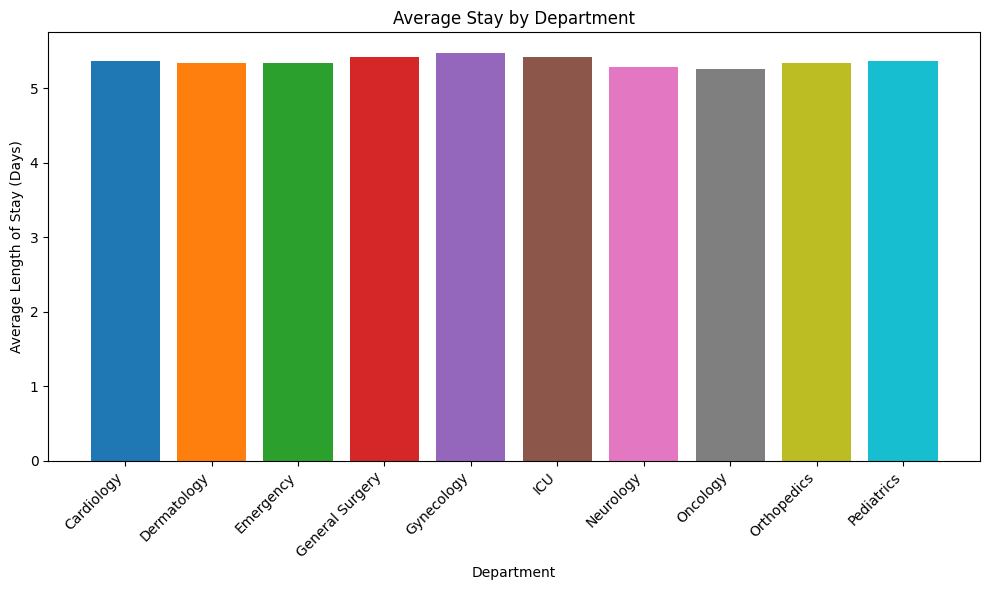

In [17]:
import matplotlib.pyplot as plt

stay = df.groupby("Department_Patient")["Length_of_Stay_Days"].mean()

plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(range(len(stay)))

plt.bar(stay.index, stay.values, color=colors)

plt.title("Average Stay by Department")
plt.xlabel("Department")
plt.ylabel("Average Length of Stay (Days)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Overall Business Insights

# Patient Distribution
Q1. Which department has the highest number of patients?
Answer: Dermatology has the highest number of patients, with approximately 10,200 patients.

Q2. Which department has the lowest number of patients?
Answer: Pediatrics has the lowest number of patients, with approximately 9,800 patients.

# Facility Utilization
Q3. Which hospital treated the highest number of patients?
Answer: Fortis Hospital treated the highest number of patients, with approximately 8,600 patients.

Q4. Which hospital treated the lowest number of patients?
Answer: PGIMER treated the lowest number of patients, with approximately 2,600 patients.

Q5. Which hospital type handled more patients?
Answer: Private Hospitals handled more patients, accounting for 62.4% (62,384 patients), compared with 37.6% (37,616 patients) in Government Hospitals.

# Severity / Treatment Volume
Q6. Which severity level has the highest number of patients?
Answer: Low severity has the highest number of patients, with 40,094 patients (40.1%).

Q7. Which severity level has the lowest number of patients?
Answer: Critical severity has the lowest number of patients, with 4,960 patients (5.0%).

Q8. How many patients are included in the analysis?
Answer: A total of 100,000 patients are included in the analysis.

Q9. How many departments are available in the dataset?
Answer: The dataset contains 10 departments.

# Department Workload & Treatment Cost
Q10. Which department has the highest average treatment cost?
Answer: General Surgery has the highest average treatment cost of $4,998.

Q11. Which department has the lowest average treatment cost?
Answer: Oncology has the lowest average treatment cost of $4,735.

Q12. Which department has the highest average length of stay?
Answer: Gynecology has the highest average length of stay, at approximately 5.5 days.

Q13. Which department has the lowest average length of stay?
Answer: Oncology has the lowest average length of stay, at approximately 5.2 days.

# Overall Facility KPIs
Q14. What is the average hospital bed capacity?
Answer: The average hospital bed capacity is 1,120 beds.

Q15. How many patients recovered?
Answer: A total of 68,568 patients recovered

# CONCLUSION

The Treatment Facility Analysis provides valuable insights into hospital operations by examining patient distribution, department workload, hospital utilization, severity levels, treatment costs, and average length of stay. The dashboard highlights variations in patient demand and healthcare resource utilization across different facilities and departments.

These findings can support healthcare administrators in optimizing hospital capacity, improving resource allocation, reducing operational bottlenecks, and enhancing overall patient care. The interactive visualizations and KPI metrics provide an effective foundation for data-driven decision-making in medical operations management.